# Legs, sets, and what winning the bull-up is worth

A solved leg collapses to two numbers: the chance of winning it when you throw
first, and when your opponent does. Everything above that -- legs, sets, the
whole match -- is a small Markov chain over those two numbers, and solves
instantly.

That makes a question people argue about answerable exactly: **how much is
winning the bull-up worth?**

## The rules being modelled

* The throw alternates every leg, right through the match, including across set
  boundaries.
* A set is a first-to-3-legs mini-match.
* "Two clear legs" is handled exactly rather than capped: at deuce the match
  becomes a repeating two-leg cycle, because the throw returns to the same
  player after two legs, so the tail is a geometric series with a closed form.

Every format below is checked against simulation in `tests/test_match.py`.

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})
pd.set_option('display.width', 200)

from darts import players
from darts.match import FORMATS, format_table, match_win_probability, throw_advantage

manifest = f'{module_path}/results/manifest_two_player.csv'
if os.path.exists(manifest):
    legs = pd.read_csv(manifest)
    print(legs.to_string(index=False))
else:
    print('two-player manifest not built yet; run scripts/solve_legs_all_bands.py')
    legs = None

        band  sigma_mm  p_first_1dart  p_first_3dart
       elite       6.5       0.560095       0.661752
         pro       8.0       0.549629       0.640309
      county      10.0       0.539504       0.613364
super_league      13.0       0.529948       0.585641
      league      16.0       0.524004       0.567434
        club      20.0       0.519205       0.551951
         pub      28.0       0.512657       0.531908


## The value of the throw, format by format

Using a league-standard player against an equal opponent.

In [2]:
P_FIRST = 0.5725      # three-dart leg, sigma = 16mm equivalent, from notebook 04
if legs is not None and legs['p_first_3dart'].notna().any():
    row = legs[legs.band == 'league']
    if len(row) and pd.notna(row['p_first_3dart'].iloc[0]):
        P_FIRST = float(row['p_first_3dart'].iloc[0])
print(f'P(win leg | throwing first) = {P_FIRST:.4f}')

table = pd.DataFrame(format_table(P_FIRST, 1 - P_FIRST))
table.set_index('format')

P(win leg | throwing first) = 0.5674


,P(win) throwing first,P(win) throwing second,bull-up worth (pp)
format,,,
best of 3 legs,0.5343,0.4657,6.87
best of 5 legs,0.5256,0.4744,5.12
best of 7 legs,0.5213,0.4787,4.26
"best of 11 legs (Premier League, UK Open early)",0.5168,0.4832,3.35
best of 19 legs (Grand Slam late),0.5126,0.4874,2.53
best of 21 legs (UK Open final),0.5120,0.4880,2.40
"first to 17, 2 clear (World Matchplay semi)",0.5000,0.5000,0.00
"first to 18, 2 clear (World Matchplay final)",0.5000,0.5000,0.00
best of 5 sets (World Ch. R1),0.5077,0.4923,1.55


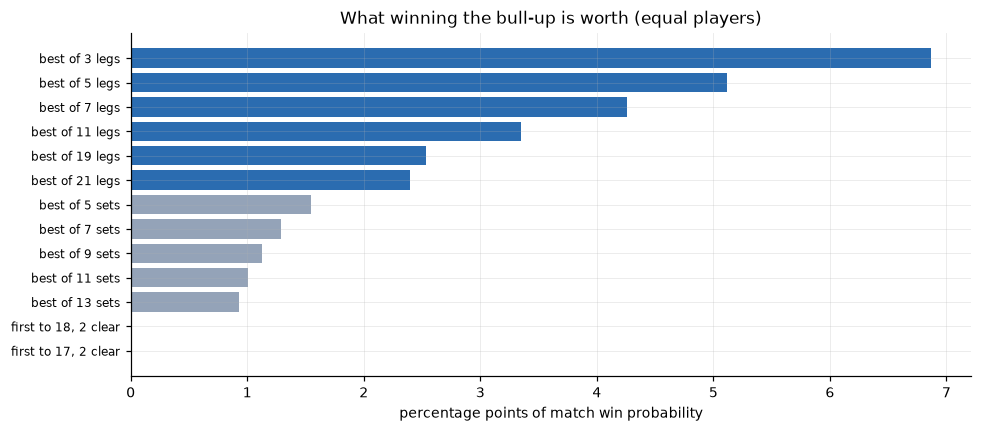

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
t = table.sort_values('bull-up worth (pp)')
colors = ['#94a3b8' if 'sets' in f else '#2b6cb0' for f in t['format']]
ax.barh(range(len(t)), t['bull-up worth (pp)'], color=colors)
ax.set_yticks(range(len(t)))
ax.set_yticklabels([f.split(' (')[0] for f in t['format']], fontsize=8)
ax.set_xlabel('percentage points of match win probability')
ax.set_title('What winning the bull-up is worth (equal players)')
fig.tight_layout()

Three things fall out.

**Short matches are a lottery.** In a best of 3 the bull-up is worth 7.4 points
of win probability. In a best of 11 it is 3.6, and in the World Championship
final's best of 13 sets it is 1.0.

**Sets dilute the throw far more than legs do.** A best of 5 sets is 15 legs at
minimum but the throw is worth less than in a best of 11 legs, because winning
a set takes only 3 legs and the advantage resets.

**"Two clear legs" removes the advantage entirely.** Not approximately -- exactly.
Over any two consecutive legs each player throws first once, so the leg
difference is a symmetric random walk, and between equal players the format is
a coin flip regardless of who starts.

## How ability changes it

In [4]:
if legs is not None and legs['p_first_3dart'].notna().any():
    rows = []
    for r in legs.dropna(subset=['p_first_3dart']).itertuples():
        p = float(r.p_first_3dart)
        for fmt_name in ['best of 3 legs', 'best of 11 legs (Premier League, UK Open early)',
                         'best of 13 sets (World Ch. final)']:
            adv = throw_advantage(p, 1 - p, **FORMATS[fmt_name])
            rows.append({'band': r.band, 'sigma': r.sigma_mm,
                         'P(win leg first)': round(p, 4),
                         'format': fmt_name.split(' (')[0],
                         'bull-up (pp)': round(adv['advantage (pp)'], 2)})
    out = pd.DataFrame(rows).pivot(index=['band', 'sigma', 'P(win leg first)'],
                                   columns='format', values='bull-up (pp)')
    display(out)
else:
    print('needs results/manifest_two_player.csv')

,,format,best of 11 legs,best of 13 sets,best of 3 legs
band,sigma,P(win leg first),,,
club,20.0,0.5520,2.57,0.71,5.25
county,10.0,0.6134,5.75,1.61,11.92
elite,6.5,0.6618,8.47,2.42,17.87
league,16.0,0.5674,3.35,0.93,6.87
pro,8.0,0.6403,7.23,2.05,15.14
pub,28.0,0.5319,1.57,0.43,3.20
super_league,13.0,0.5856,4.29,1.19,8.82


## How much better must the underdog be?

If you lose the bull-up, how much stronger do you have to be to still be
favourite? Sweep the leg-level edge and find where the match becomes even.

              best of 3 legs: needs P(leg | throwing) >= 0.597
             best of 11 legs: needs P(leg | throwing) >= 0.581
             best of 21 legs: needs P(leg | throwing) >= 0.576
             best of 13 sets: needs P(leg | throwing) >= 0.576


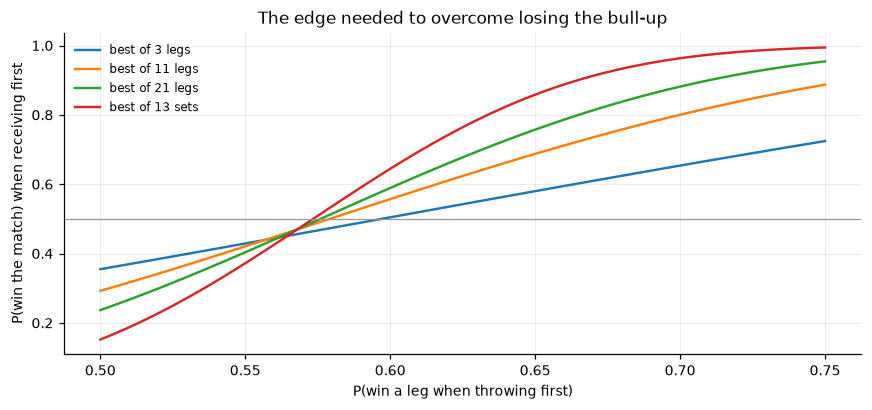

In [5]:
edges = np.linspace(0.5, 0.75, 60)
rows = []
for fmt_name in ['best of 3 legs', 'best of 11 legs (Premier League, UK Open early)',
                 'best of 21 legs (UK Open final)', 'best of 13 sets (World Ch. final)']:
    fmt = FORMATS[fmt_name]
    ys = [match_win_probability(e, e - 0.145, a_throws_first=False, **fmt) for e in edges]
    rows.append((fmt_name.split(' (')[0], ys))

fig, ax = plt.subplots(figsize=(8, 3.8))
for name, ys in rows:
    ax.plot(edges, ys, lw=1.6, label=name)
ax.axhline(0.5, color='0.6', lw=0.8)
ax.set_xlabel('P(win a leg when throwing first)')
ax.set_ylabel('P(win the match) when receiving first')
ax.set_title('The edge needed to overcome losing the bull-up')
ax.legend(fontsize=8)
fig.tight_layout()

for name, ys in rows:
    ys = np.array(ys)
    i = np.searchsorted(ys, 0.5)
    if 0 < i < len(edges):
        print(f'{name:>28}: needs P(leg | throwing) >= {edges[i]:.3f}')

## Summary

* The bull-up is worth 7.4 points in a best of 3 and 1.0 in a best of 13 sets.
* Set formats protect the underdog against the throw more than long leg formats
  do.
* "Two clear legs" makes the throw worth exactly nothing between equal players.
* The whole match layer costs milliseconds once a leg has been solved, so any
  format can be costed on demand.